# Исследование ёмкости embedding векторов, когда кол-во фичей >> размерности эмбеддинга (over размерности базиса)

In [1]:
# @launchit.collected

In [2]:
import os # @launchit.collect
import sys # @launchit.collect
import copy
from collections import namedtuple, defaultdict, Counter # @launchit.collect
import itertools
import json
import datetime
import pprint
from functools import cache
import re
import pickle
from unittest.mock import Mock
import dataclasses # @launchit.collect
from dataclasses import dataclass # @launchit.collect
import IPython
from enum import Flag, StrEnum, auto # @launchit.collect
import multiprocessing as mp

from tqdm.notebook import tqdm

import numpy as np
import einops
import matplotlib.pyplot as plt

import torch
import torch.nn as nn
import torch.nn.functional as F
import torch.optim
from torch.autograd import grad as torch_grad
from torch.utils.data import DataLoader

import optuna 
from optuna.storages import JournalStorage 
from optuna.storages.journal import JournalFileBackend 
from optuna.trial import TrialState

project_root_path = '${PROJECT_ROOT_PATH}' # @launchit.collect
# @launchit.disable
project_root_path = ! git rev-parse --show-toplevel
project_root_path = project_root_path[0]
# @launchit.stop

sys.path.append('.')
sys.path.append(os.path.join(project_root_path, 'lib')) # @launchit.collect
from utils import * # @launchit.collect
from logging_utils import *
from model_registry import *
import launchit # @launchit.disable
import optuna_multiprocessing  # @launchit.collect_2
from metrics_collector import RmqSummaryWriter
from autoincrement import Autoincrement
from torch_helpers import *
from hp_utils import *
from model_units import *

# Setup

In [3]:
ArrayUtils.init()
xp = ArrayUtils.xp
LOG = Logging.get()
RNG = np.random.default_rng()
METRICS_SUITE = defaultdict(list)

class ExecMode(StrEnum):
    MASTER_NOTEBOOK = auto()
    LAUNCH_NOTEBOOK = auto()
    LAUNCH_MODULE = auto()

CONFIG = namedtuple('Config', 
                    'project_root_path, project_root_uri, subproject_path, data_path, private_data_path, run_path, ' + 
                    'self_fname, self_name, ' +
                    'subproject_name,' +
                    'is_cuda, cuda_device, exec_mode, is_interactive')(
    project_root_path=project_root_path,
    project_root_uri=f'com.develorium.{os.path.basename(project_root_path)}',
    subproject_path=os.path.abspath('.'),
    data_path=os.path.join(project_root_path, 'data'),
    private_data_path=None,
    run_path='',
    self_fname='',
    self_name='',
    subproject_name='',
    is_cuda=torch.cuda.is_available(),
    cuda_device='cuda' if torch.cuda.is_available() else 'cpu',
    exec_mode=ExecMode.MASTER_NOTEBOOK,
    is_interactive=True,
)

if IPython.get_ipython() is None:
    module_fname = __file__
    module_basename = os.path.basename(module_fname)
    module_name, _ = os.path.splitext(module_basename)
    
    CONFIG = CONFIG._replace(self_fname=module_fname, self_name=module_name)
    CONFIG = CONFIG._replace(exec_mode=ExecMode.LAUNCH_MODULE)
else:
    with open(IPython.get_ipython().kernel.config['IPKernelApp']['connection_file'], 'r') as cf:
        notebook_fname = json.load(cf)['jupyter_session']
        notebook_basename = os.path.basename(notebook_fname)
        notebook_name, notebook_ext = os.path.splitext(notebook_basename)
    
        m = re.match(r'(\w+)-Copy\d+$', notebook_name)
    
        if m: notebook_name = m.group(1) # e.g. Cuml is used to be launched from the copy of the notebook

        CONFIG = CONFIG._replace(self_fname=notebook_fname, self_name=notebook_name)
        
        is_launch = re.match(r'\w+-launch\d+$', notebook_name) is not None
        CONFIG = CONFIG._replace(exec_mode=ExecMode.MASTER_NOTEBOOK if not is_launch else ExecMode.LAUNCH_NOTEBOOK)

CONFIG = CONFIG._replace(is_interactive=CONFIG.exec_mode != ExecMode.LAUNCH_MODULE)

LOG.app_name = CONFIG.self_name
LOG.enable('syslog', not CONFIG.is_interactive)
LOG.enable('stdout', CONFIG.is_interactive)

CONFIG = CONFIG._replace(subproject_name=os.path.basename(os.path.dirname(CONFIG.self_fname)))
CONFIG = CONFIG._replace(run_path=os.path.join(project_root_path, 'run', CONFIG.subproject_name))
CONFIG = CONFIG._replace(private_data_path=os.path.join(CONFIG.data_path, CONFIG.subproject_name))
LOG(f'CONFIG=\n{pprint.pformat(CONFIG._asdict(), sort_dicts=False)}\n', when=CONFIG.is_interactive)
LOG(f'CONFIG={CONFIG._asdict()}', when=not CONFIG.is_interactive)

os.makedirs(CONFIG.private_data_path, exist_ok=True)
os.makedirs(CONFIG.run_path, exist_ok=True)

CONFIG=
{'project_root_path': '/home/misha/dev/mine/neurovision',
 'project_root_uri': 'com.develorium.neurovision',
 'subproject_path': '/home/misha/dev/mine/neurovision/14_embedding',
 'data_path': '/home/misha/dev/mine/neurovision/data',
 'private_data_path': '/home/misha/dev/mine/neurovision/data/14_embedding',
 'run_path': '/home/misha/dev/mine/neurovision/run/14_embedding',
 'self_fname': '/home/misha/dev/mine/neurovision/14_embedding/over_capacity_emb_01.ipynb',
 'self_name': 'over_capacity_emb_01',
 'subproject_name': '14_embedding',
 'is_cuda': True,
 'cuda_device': 'cuda',
 'exec_mode': <ExecMode.MASTER_NOTEBOOK: 'master_notebook'>,
 'is_interactive': True}



In [4]:
# @launchit.disable
# @launchit.collect
class LaunchGoal(StrEnum):
    UNSPECIFIED = auto()
    DECORRELATE_FEATURES = auto()

class LaunchGoalObj(namedtuple('LaunchGoalObj', 'goal, model_group_uri, model_name, model_version, model_main_asset_fname')):
    def matches(self, *g):
        if CONFIG.exec_mode == ExecMode.MASTER_NOTEBOOK:
            return True
            
        if g and isinstance(g[0], list):
            assert len(g) == 1
            return self.goal in g[0]

        return self.goal in g

LAUNCH_GOAL = LaunchGoalObj(
    goal=LangUtils.from_str(LaunchGoal, '${LAUNCH_GOAL}', LaunchGoal.UNSPECIFIED),
    model_group_uri='${MODEL_GROUP_URI}',
    model_name='${MODEL_NAME}',
    model_version=LangUtils.from_str(int, '${MODEL_VERSION}', 0),
    model_main_asset_fname='${LAUNCHIT_FNAME}',
)
# @launchit.stop

LAUNCH_GOAL = LAUNCH_GOAL._replace(goal=LaunchGoal.UNSPECIFIED)
LAUNCH_GOAL = LAUNCH_GOAL._replace(model_group_uri=f'{CONFIG.project_root_uri}.{CONFIG.subproject_name}')
LAUNCH_GOAL = LAUNCH_GOAL._replace(model_name=CONFIG.self_name)
LAUNCH_GOAL = LAUNCH_GOAL._replace(model_version=0)
LAUNCH_GOAL = LAUNCH_GOAL._replace(model_main_asset_fname=CONFIG.self_fname)
# @launchit.stop

LOG(f'LAUNCH_GOAL=\n{pprint.pformat(LAUNCH_GOAL._asdict(), sort_dicts=False)}', when=CONFIG.is_interactive)
LOG(f'LAUNCH_GOAL={LAUNCH_GOAL._asdict()}', when=not CONFIG.is_interactive)

LAUNCH_GOAL=
{'goal': <LaunchGoal.UNSPECIFIED: 'unspecified'>,
 'model_group_uri': 'com.develorium.neurovision.14_embedding',
 'model_name': 'over_capacity_emb_01',
 'model_version': 0,
 'model_main_asset_fname': '/home/misha/dev/mine/neurovision/14_embedding/over_capacity_emb_01.ipynb'}


# Hyperparameters

In [5]:
# @launchit.disable
# @launchit.collect
@dataclass
class Hyperparameters:
    random_seed: int = None
    # model params
    embedding_size: int = None # ES
    features_bank_size: int = None # FBS - сколько всего фичей знает система. Банк знаний
    features_count: int = None # FC - сколько фичей (их значений) мы хотим записать в один HDV. 
    feature_value_range: tuple = None # (1,1) - binary features, (0.5, 1) - real valued features
    encode_bias: str = None # none, 'scalar', 'vector'
    decode_bias: str = None # none, 'scalar', 'vector'
    nonlinearity: str = None
    # learning params
    with_normalization: bool = None
    batch_size: int = None
    epochs_count: int = None
    loss: str = None
    learn_rate: float | str = None

    @staticmethod
    def from_dict(d):
        hp = Hyperparameters(**d)
        return hp

    def _asdict(self):
        return dataclasses.asdict(self)

HP = Hyperparameters()
HP.random_seed = 1


# Launch

## new_model_registry

In [6]:
def new_model_registry(is_real=None, group_uri=None):
    is_launch = CONFIG.exec_mode in [ExecMode.LAUNCH_NOTEBOOK, ExecMode.LAUNCH_MODULE]
    is_real = is_real if is_real is not None else is_launch

    if not is_real:
        mr = Mock()
        mr.register_model.return_value = 0
        return mr
        
    return ModelRegistry(LAUNCH_GOAL.model_group_uri if group_uri is None else group_uri)

## new_summary_writer

In [7]:
def new_summary_writer(log_dir, is_real=None):
    is_launch = CONFIG.exec_mode in [ExecMode.LAUNCH_NOTEBOOK, ExecMode.LAUNCH_MODULE]
    is_real = is_real if is_real is not None else is_launch

    if not is_real:
        sw = Mock()
        sw.flush.side_effect = sw.reset_mock # to get rid of all recorded call_args_list, which might be heavy (e.g. add_figure)
        return sw
    
    return RmqSummaryWriter(log_dir)

## Bootstrap

In [8]:
optuna_trial = optuna_multiprocessing.get_trial()
optuna_trial_subdir_name = ''

if optuna_trial is not None:
    optuna_trial.set_user_attr('MODEL_VERSION', LAUNCH_GOAL.model_version)
    study_serial = optuna_trial.user_attrs['STUDY_SERIAL']
    optuna_trial_subdir_name = f'opt_{study_serial}'
    LOG(f'Optuna {optuna_trial.number=}, {optuna_trial.user_attrs=}')

LOG(f'HP={HP._asdict()}', when=not CONFIG.is_interactive)
    
if HP.random_seed is not None:
    torch.manual_seed(HP.random_seed)
    RNG = np.random.default_rng(HP.random_seed)    
    LOG(f'Random seed={HP.random_seed}')

if True or LAUNCH_GOAL.goal != LaunchGoal.TRAIN_MODEL_AFTER_CV:
    model_registry = new_model_registry()
    model_registry.attach_asset(LAUNCH_GOAL.model_name, LAUNCH_GOAL.model_version, CONFIG.self_fname, replace=True)
        
    meta = dict(
        optuna_trial_number=getattr(optuna_trial, 'number', None),
        hypers=HP._asdict(), 
        config=CONFIG._asdict(), 
    )
    
    with io.StringIO() as b:
        json.dump(meta, b)
        model_registry.attach_asset(LAUNCH_GOAL.model_name, LAUNCH_GOAL.model_version, b, asset_ext='json', asset_classifier='meta', replace=True)

summary_log_dir = LAUNCH_GOAL.model_name
summary_log_dir = os.path.join(summary_log_dir, optuna_trial_subdir_name) if optuna_trial_subdir_name != '' else summary_log_dir 
summary_log_dir = os.path.join(summary_log_dir, str(LAUNCH_GOAL.model_version))
LOG(f'Tensorboard run={summary_log_dir}')
summary_writer = new_summary_writer(log_dir=summary_log_dir)
summary_writer.add_text('hypers', pprint.pformat(HP._asdict(), sort_dicts=False), 1)
summary_writer.add_text('config', pprint.pformat(CONFIG._asdict(), sort_dicts=False), 1)

Random seed=1
Tensorboard run=over_capacity_emb_01/0


<Mock name='mock.add_text()' id='135125785820768'>

# Model

In [9]:
class MainModel(nn.Module):
    def __init__(self, hp):
        super().__init__()
        
        self.features = RNG.uniform(-1, +1, size=(hp.features_bank_size, hp.embedding_size)).astype('float32')
        self.features = (self.features.T / np.linalg.norm(self.features, axis=1)).T
        self.features = nn.Parameter(torch.tensor(self.features))

        if LangUtils.coalesce(hp.encode_bias, False):
            match hp.encode_bias:
                case 'scalar': self.encode_bias = nn.Parameter(torch.tensor(0.))
                case 'vector': self.encode_bias = nn.Parameter(torch.zeros(hp.features_bank_size))
                case _: assert False, f'Unsupported {hp.encode_bias=}'
        else:
            self.encode_bias = None

        if LangUtils.coalesce(hp.decode_bias, False):
            match hp.decode_bias:
                case 'scalar': self.decode_bias = nn.Parameter(torch.tensor(0.))
                case 'vector': self.decode_bias = nn.Parameter(torch.zeros(hp.features_bank_size))
                case _: assert False, f'Unsupported {hp.decode_bias=}'
        else:
            self.decode_bias = None

        if LangUtils.coalesce(hp.nonlinearity, False):
            self.nonlinearity = getattr(nn, hp.nonlinearity)()
        else:
            self.nonlinearity = lambda i: i
            
    def forward(self, batch):
        # every item in batch is a disentangled representation, i.e. one feature = one slot
        if self.encode_bias is not None:
            mask = torch.where(batch > 0, 1, 0)
            batch = batch + mask * self.encode_bias # adjust values only for present features (don't use += to avoid requires_grad_ to be set on batch with propagating outwards)
        
        # encode -> make embedding for each sample in batch: scale each feature by corresponding value, sum all features (disentagled to distributed representation)
        # mnemonics 1: feature (axes) are in columns, samples are in columns
        embeddings = (self.features.T @ batch.T).T # similar to (batch @ self.features), mnemonics 4
        # decode -> extract feature values from embedding by projecting it on feature axes
        # mnemonics 5: embedding in rows, features in columns, getting dot products, and since self.features is normalized, then dot products equal to the value of projection
        decoded = embeddings @ self.features.T

        if self.decode_bias is not None:
            decoded -= self.decode_bias
        
        return self.nonlinearity(decoded)

In [10]:
# @launchit.disable
model_hp = Hyperparameters(embedding_size=100, features_bank_size=200, encode_bias='vector', decode_bias='scalar')
model = MainModel(model_hp)
probe_tensor = torch.ones(10, model_hp.features_bank_size)
res = model(probe_tensor)
print(model)
print(f'Parameters count={sum([p.numel() for p in model.parameters()]):_}')
print(f'Input shape={probe_tensor.shape}')
print(f'Output shape={res.shape}')

MainModel()
Parameters count=20_201
Input shape=torch.Size([10, 200])
Output shape=torch.Size([10, 200])


# LaunchGoal.DECORRELATE_FEATURES

## Configure

In [11]:
# @launchit.disable
# @launchit.collect_1
HP.embedding_size = 768
HP.features_bank_size = 100_000
HP.features_count = 100
HP.feature_value_range = (0.05, 1)
HP.encode_bias = None
HP.decode_bias = None
HP.with_normalization = True
HP.nonlinearity = 'ReLU'
HP.batch_size = 100
HP.epochs_count = 10_000
HP.loss = 'loss_tp'
HP.learn_rate = 0.0001
# @launchit.stop
LOG(pprint.pformat(HP._asdict(), sort_dicts=False), when=CONFIG.is_interactive)

{'random_seed': 1,
 'embedding_size': 768,
 'features_bank_size': 100000,
 'features_count': 100,
 'feature_value_range': (0.05, 1),
 'encode_bias': None,
 'decode_bias': None,
 'nonlinearity': 'ReLU',
 'with_normalization': True,
 'batch_size': 100,
 'epochs_count': 10000,
 'loss': 'loss_tp',
 'learn_rate': 0.0001}


## Create

In [ ]:
model = MainModel(HP).to(CONFIG.cuda_device)

## Visualize before

In [ ]:
# Manually build histogram because building full cos_sims matrix requires too much memory (doesn't fit into GPU)
def get_feature_cos_sims_histogram(features, method=1, buckets_count=10):
    min_cos_sim, max_cos_sim = 0, 0
    
    for features_batch in tqdm(DataLoader(features, batch_size=1000), leave=False):
        cos_sims = features_batch @ features.T
        min_cos_sim = min(min_cos_sim, cos_sims.min().item())
        max_cos_sim = max(max_cos_sim, cos_sims.max().item())
    
    if method == 1:
        buckets = Counter()
        
        for features_batch in tqdm(DataLoader(features, batch_size=1000), leave=False):
            cos_sims = (features_batch @ features.T).ravel()
            # map each cos_sim to 0..1 (where 0 stands for min_cos_sim 1 - max_cos_sim)
            cos_sims = (cos_sims - min_cos_sim) / (max_cos_sim - min_cos_sim)
            # map each cos_sim to bucket index
            bucket_indices = (cos_sims * buckets_count).to(int)
            buckets.update(dict(zip(*np.unique_counts(bucket_indices.cpu().numpy()))))

        step = (max_cos_sim - min_cos_sim) / buckets_count
        bucket_centers = list(map(lambda i: min_cos_sim + step * i + step / 2, np.arange(buckets_count)))
        buckets = list(map(lambda i: buckets.get(i, 0), np.arange(buckets_count)))
        return buckets, bucket_centers
    elif method == 2:
        # Equivalent but a little bit slower code
        buckets = None
        
        for features_batch in tqdm(DataLoader(features, batch_size=1000), leave=False):
            cos_sims = (features_batch @ features.T).ravel()
            h = np.histogram(cos_sims.cpu().numpy(), bins=buckets_count, range=(min_cos_sim, max_cos_sim))
        
            if buckets is None:
                buckets = h
            else:
                assert np.all(buckets[1] == h[1])
                buckets[0][:] = buckets[0] + h[0]

        bucket_centers = list(map(lambda x: (x[0] + x[1]) / 2, zip(h[1][0:], h[1][1:])))
        return buckets, bucket_centers

In [ ]:
# @launchit.disable
buckets, bucket_centers = get_feature_cos_sims_histogram(model.features.detach())
labels = list(map(lambda i: f'{i:.2f}', bucket_centers))
plt.title('Features correlation before')
plt.bar(labels, buckets);

## Optimize

In [23]:
# decorrelate feature axes by gradient descent optimization procedure
optimizer = torch.optim.Adam(model.parameters(), lr=HP.learn_rate)

def calc_loss(loss_fn, with_grad):
    if with_grad:
        return loss_fn()
    else:
        with torch.no_grad():
            return loss_fn()

for epoch in tqdm(range(HP.epochs_count + 1), disable=not CONFIG.is_interactive):
    with LOG.auto_prefix('EPOCH', epoch):
        losses = {}
        optimizer.zero_grad()
        
        # batch will have samples of disentagled representation of features (1 feature = 1 slot)
        batch = np.zeros((HP.batch_size, HP.features_bank_size), dtype='float32')
    
        for i in range(len(batch)):
            feature_inds = RNG.choice(HP.features_bank_size, HP.features_count, replace=False)
            batch[i,feature_inds] = RNG.uniform(*HP.feature_value_range, size=HP.features_count).astype('float32')
    
        batch = torch.tensor(batch, device=CONFIG.cuda_device)
        batch_hat = model(batch)
    
        mask = batch > 0
        diff = batch - batch_hat
        losses['loss_tp'] = calc_loss(lambda: (diff[mask] ** 2).mean(), with_grad=HP.loss == 'loss_tp')
        losses['loss_fp'] = calc_loss(lambda: (diff[~mask] ** 2).mean(), with_grad=HP.loss == 'loss_fp')
        losses['loss_all'] = calc_loss(lambda: (diff ** 2).mean(), with_grad=HP.loss == 'loss_all')
        losses['loss'] = losses[HP.loss]
        loss = losses[HP.loss]
    
        if epoch > 0:
            loss.backward()
            optimizer.step()
            
            if HP.with_normalization:
                # normalize feature axes (bases) so they all have unit length
                with torch.no_grad():
                    model.features[:] = (model.features.T / torch.linalg.vector_norm(model.features, dim=1)).T
    
        if (epoch % 20) == 0:
            if epoch == 0:
                example_feature_inds = RNG.choice(HP.features_bank_size, HP.features_count, replace=False)
                example = np.zeros(HP.features_bank_size, dtype='float32')
                example[example_feature_inds] = RNG.uniform(*HP.feature_value_range, size=HP.features_count).astype('float32')
                example_batch = torch.tensor(einops.rearrange(example, 'v -> 1 v'), device=CONFIG.cuda_device)
                
            model.eval()
            
            with torch.no_grad(): 
                example_batch_hat = model(example_batch)
                example_hat = example_batch_hat[0].detach().cpu().numpy()
            
                fig, (ax1, ax2, ax3) = plt.subplots(3, 1)
                fig.set_figwidth(18)
                fig.set_figheight(8)
                true_feature_values = example[example_feature_inds]
                decoded_feature_values = example_hat[example_feature_inds]
                ax1.set_title('True')
                ax1.bar(np.arange(len(true_feature_values)), true_feature_values)
                ax1.set_ylim(0, 1)
                ax2.set_title('Decoded')
                ax2.bar(np.arange(len(decoded_feature_values)), decoded_feature_values, label='Decoded')
                ax2.set_ylim(0, 1)
                diff = (true_feature_values - decoded_feature_values)
                ax3.set_title(f'Error, MSE_mean={(diff ** 2).mean():.2f}, MSE_sum={(diff ** 2).sum():.2f}, L1_mean={np.abs(diff).mean():.2f}, L1_sum={np.abs(diff).sum():.2f}')
                ax3.bar(np.arange(len(true_feature_values)), diff)
                ax3.set_ylim(-1, 1);
                fig.tight_layout();
                summary_writer.add_figure(f'example', fig, epoch, close=False) 
                plt.close(fig) # doing a manual close because summary_writer may be in Mock mode leaving figure unclosed
                LOG('Figure "example" attached', when=not CONFIG.is_interactive)
                
            model.train()
    
        for name, value in losses.items():
            summary_writer.add_scalar(name, value.item(), epoch)
            LOG(f'{name}={value.item():.4f}', when=not CONFIG.is_interactive)
            METRICS_SUITE[name].append(value.item())
            
        summary_writer.flush()

  0%|          | 0/11 [00:00<?, ?it/s]

## Visualize after

  0%|          | 0/100 [00:00<?, ?it/s]

  0%|          | 0/100 [00:00<?, ?it/s]

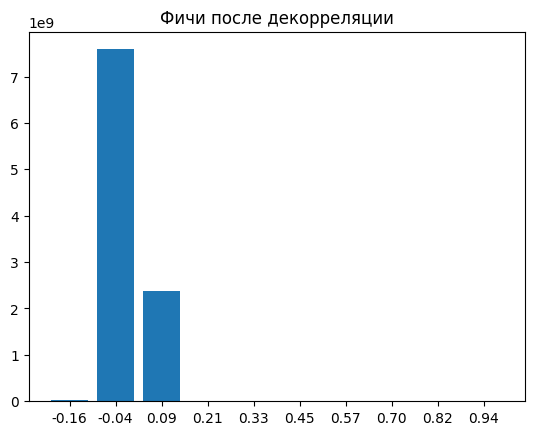

In [19]:
# @launchit.disable
buckets, bucket_centers = get_feature_cos_sims_histogram(model.features.detach())
labels = list(map(lambda i: f'{i:.2f}', bucket_centers))
plt.title('Features correlation after')
plt.bar(labels, buckets);

In [ ]:
# @launchit.disable
example_feature_inds = RNG.choice(HP.features_bank_size, HP.features_count, replace=False)
example = np.zeros(HP.features_bank_size, dtype='float32')
example[example_feature_inds] = RNG.uniform(*HP.feature_value_range, size=HP.features_count).astype('float32')
example_batch = torch.tensor(einops.rearrange(example, 'v -> 1 v'), device=CONFIG.cuda_device)
example_batch_hat = model(example_batch)
example_hat = example_batch_hat[0].detach().cpu().numpy()

fig, (ax1, ax2, ax3) = plt.subplots(3, 1)
fig.set_figwidth(18)
fig.set_figheight(8)
true_feature_values = example[example_feature_inds]
decoded_feature_values = example_hat[example_feature_inds]
ax1.set_title('True')
ax1.bar(np.arange(len(true_feature_values)), true_feature_values)
ax1.set_ylim(0, 1)
ax2.set_title('Decoded')
ax2.bar(np.arange(len(decoded_feature_values)), decoded_feature_values, label='Decoded')
ax2.set_ylim(0, 1)
diff = (true_feature_values - decoded_feature_values)
ax3.set_title(f'Error, MSE_mean={(diff ** 2).mean():.2f}, MSE_sum={(diff ** 2).sum():.2f}, L1_mean={np.abs(diff).mean():.2f}, L1_sum={np.abs(diff).sum():.2f}')
ax3.bar(np.arange(len(true_feature_values)), diff)
ax3.set_ylim(-1, 1);
fig.tight_layout();

**ВЫВОДЫ**

Видно, что декорреляция "в лоб", когда FBS>>ES, ничего не даёт. В одном месте улучшаем, тут же ломается в другом месте, поэтому и видны "метания".

## Save Optuna trial result

In [ ]:
# @launchit.disable_1
optuna_trial = optuna_multiprocessing.get_trial()

if optuna_trial is not None and LAUNCH_GOAL.goal == LaunchGoal.DECORRELATE_FEATURES:
    if 'IS_PRUNED' in optuna_trial.user_attrs:
        raise optuna.exceptions.TrialPruned()

    if not METRICS_SUITE:
        LOG(f'Empty metrics suite. Cancelling trial')
        raise Exception('Empty metrics suite')
    else:
        last_loss = METRICS_SUITE['loss'][-1]
        optuna_multiprocessing.save_trial_result(last_loss)
        LOG(f'Trial objective result: {last_loss=}')

# Launch creation

## DECORRELATE_FEATURES

In [12]:
# @launchit.disable
launchit_t0 = time.time()

In [13]:
# @launchit.disable
launchit_interval = time.time() - launchit_t0

if launchit_interval > 0.05:
    model_version = int(Autoincrement.get(f'{LAUNCH_GOAL.model_group_uri}.{LAUNCH_GOAL.model_name}'))
    assert model_version > 0, model_version
    model_registry_obj = new_model_registry(is_real=True)
    model_registry_obj.register_model(LAUNCH_GOAL.model_name, model_version)
    LOG(f'Model instance registered, version={model_version}')
    
    expandvars = dict(
        PROJECT_ROOT_PATH=CONFIG.project_root_path,
        MODEL_GROUP_URI=LAUNCH_GOAL.model_group_uri,
        MODEL_NAME=LAUNCH_GOAL.model_name,
        MODEL_VERSION=model_version,
        LAUNCH_GOAL=LaunchGoal.DECORRELATE_FEATURES,
    )
    launch_notebook_fname = launchit.launchit(CONFIG.self_fname, launch_serial=model_version, expandvars=expandvars, collect_inds=[1], disable_inds=[])
    LOG(f'Created launch notebook "{launch_notebook_fname}"')
else:
    LOG('Skip launchit due to mass "Run Cells"')

Model instance registered, version=10
Creating /home/misha/dev/mine/neurovision/14_embedding/over_capacity_emb_01-launch10.ipynb
Created launch notebook "/home/misha/dev/mine/neurovision/14_embedding/over_capacity_emb_01-launch10.ipynb"


## Optuna (model selection)

### Templates

In [25]:
# @launchit.disable
# @launchit.collect_2
grid_search_spaces = {
    1: { 'encode_bias': [None, 'scalar', 'vector'], 'decode_bias': [None, 'scalar', 'vector']},
    2: { 'encode_bias': [None, 'scalar', 'vector'], 'decode_bias': [None, 'scalar', 'vector']},
    3: { 'encode_bias': [None, 'scalar', 'vector'], 'decode_bias': [None, 'scalar', 'vector']},
    4: { 'encode_bias': [None, 'scalar', 'vector'], 'decode_bias': [None, 'scalar', 'vector']},
    5: { 'encode_bias': [None, 'scalar', 'vector'], 'decode_bias': [None, 'scalar', 'vector'], 'loss': ['loss_tp', 'loss_all']},
    6: { 'encode_bias': [None, 'scalar', 'vector'], 'decode_bias': [None, 'scalar', 'vector'], 'loss': ['loss_tp', 'loss_all']},
}

def get_grid_search_space(study_serial, param_name):
    return param_name, grid_search_spaces[study_serial][param_name]

optuna_trial = optuna_multiprocessing.get_trial()

if optuna_trial is not None:
    study_serial = optuna_trial.user_attrs['STUDY_SERIAL']
    
    match study_serial:
        case 1:
            HP.random_seed = 1
            HP.embedding_size = 768
            HP.features_bank_size = 100_000
            HP.features_count = 100
            HP.feature_value_range = (0.05, 1) # real-valued features
            HP.encode_bias = optuna_trial.suggest_categorical(*get_grid_search_space(study_serial, 'encode_bias'))
            HP.decode_bias = optuna_trial.suggest_categorical(*get_grid_search_space(study_serial, 'decode_bias'))
            HP.with_normalization = True
            HP.nonlinearity = 'ReLU'
            HP.batch_size = 100
            HP.epochs_count = 5_000
            HP.loss = 'loss_tp'
            HP.learn_rate = 0.0001
        case 2:
            HP.random_seed = 1
            HP.embedding_size = 768
            HP.features_bank_size = 100_000
            HP.features_count = 100
            HP.feature_value_range = (1, 1) # binary-valued features
            HP.encode_bias = optuna_trial.suggest_categorical(*get_grid_search_space(study_serial, 'encode_bias'))
            HP.decode_bias = optuna_trial.suggest_categorical(*get_grid_search_space(study_serial, 'decode_bias'))
            HP.with_normalization = True
            HP.nonlinearity = 'ReLU'
            HP.batch_size = 100
            HP.epochs_count = 5_000
            HP.loss = 'loss_tp'
            HP.learn_rate = 0.0001
        case 3:
            HP.random_seed = 1
            HP.embedding_size = 768
            HP.features_bank_size = 100_000
            HP.features_count = 100
            HP.feature_value_range = (1, 1) # binary-valued features
            HP.encode_bias = optuna_trial.suggest_categorical(*get_grid_search_space(study_serial, 'encode_bias'))
            HP.decode_bias = optuna_trial.suggest_categorical(*get_grid_search_space(study_serial, 'decode_bias'))
            HP.with_normalization = True
            HP.nonlinearity = 'Sigmoid' # Sigmoid seems to be better - more effectifely squashes to 0 or 1
            HP.batch_size = 100
            HP.epochs_count = 5_000
            HP.loss = 'loss_tp'
            HP.learn_rate = 0.0001
        case 4:
            HP.random_seed = 1
            HP.embedding_size = 768
            HP.features_bank_size = 100_000
            HP.features_count = 100
            HP.feature_value_range = (1, 1) # binary-valued features
            HP.encode_bias = optuna_trial.suggest_categorical(*get_grid_search_space(study_serial, 'encode_bias'))
            HP.decode_bias = optuna_trial.suggest_categorical(*get_grid_search_space(study_serial, 'decode_bias'))
            HP.with_normalization = True
            HP.nonlinearity = 'Sigmoid' # Sigmoid seems to be better - more effectifely squashes to 0 or 1
            HP.batch_size = 100
            HP.epochs_count = 5_000
            HP.loss = 'loss_all'
            HP.learn_rate = 0.0001
        case 5:
            HP.random_seed = 1
            HP.embedding_size = 768
            HP.features_bank_size = 100_000
            HP.features_count = 100
            HP.feature_value_range = (0.05, 1) # real-valued features
            HP.encode_bias = optuna_trial.suggest_categorical(*get_grid_search_space(study_serial, 'encode_bias'))
            HP.decode_bias = optuna_trial.suggest_categorical(*get_grid_search_space(study_serial, 'decode_bias'))
            HP.with_normalization = False # No normalization
            HP.nonlinearity = 'ReLU'
            HP.batch_size = 100
            HP.epochs_count = 5_000
            HP.loss = optuna_trial.suggest_categorical(*get_grid_search_space(study_serial, 'loss'))
            HP.learn_rate = 0.0001
        case 6:
            HP.random_seed = 1
            HP.embedding_size = 768
            HP.features_bank_size = 100_000
            HP.features_count = 100
            HP.feature_value_range = (1, 1) # binary-valued features
            HP.encode_bias = optuna_trial.suggest_categorical(*get_grid_search_space(study_serial, 'encode_bias'))
            HP.decode_bias = optuna_trial.suggest_categorical(*get_grid_search_space(study_serial, 'decode_bias'))
            HP.with_normalization = False # No normalization
            HP.nonlinearity = 'Sigmoid'
            HP.batch_size = 100
            HP.epochs_count = 5_000
            HP.loss = optuna_trial.suggest_categorical(*get_grid_search_space(study_serial, 'loss'))
            HP.learn_rate = 0.0001
        case _:
            assert False, f'Unsupported {study_serial=}'    

### Unleash

In [27]:
# @launchit.disable
def get_optimize_directions(lg):
    match lg:
        case LaunchGoal.DECORRELATE_FEATURES:
            return ['minimize']
        case _:
            assert False, f'Unsupported {lg=}'

lg = LaunchGoal.DECORRELATE_FEATURES
expandvars = dict(
    PROJECT_ROOT_PATH=CONFIG.project_root_path,
    MODEL_GROUP_URI=LAUNCH_GOAL.model_group_uri,
    MODEL_NAME=LAUNCH_GOAL.model_name,
    LAUNCH_GOAL=lg.value,
)
study_serial = 6
study_name = f'{CONFIG.self_name}_{expandvars['LAUNCH_GOAL']}_{study_serial}'
rop_task = optuna_multiprocessing.RunOptimizationTask(
    app_name=CONFIG.self_name,
    is_stdout_enabled=False,
    notebook_fname=CONFIG.self_fname,
    notebook_name=CONFIG.self_name,
    model_group_uri=LAUNCH_GOAL.model_group_uri,
    model_name=LAUNCH_GOAL.model_name,
    expandvars=expandvars,
    collect_inds=[2],
    disable_inds=[2],
    run_path=CONFIG.run_path,
    study_serial=study_serial,
    study_name=study_name,
    study_fname=os.path.join(CONFIG.run_path, study_name + '.log'),
    optimize_directions=get_optimize_directions(lg),
    grid_search_space=grid_search_spaces.get(study_serial),
)
rop_tasks = [rop_task] * 18
mp_ctx = mp.get_context('spawn') # Req-d for CUDA, fork doesn't work within PyTorch

with mp_ctx.Pool(processes=3, maxtasksperchild=1) as pool:  # maxtasksperchild=1 forces fresh process for each trial to spare resources and avoid possible side effects of processe resue
    pool.map(optuna_multiprocessing.run_optimization, rop_tasks)

[I 2026-03-25 15:15:45,534] A new study created in Journal with name: over_capacity_emb_01_decorrelate_features_6
[I 2026-03-25 15:15:45,539] Using an existing study with name 'over_capacity_emb_01_decorrelate_features_6' instead of creating a new one.
[I 2026-03-25 15:15:45,541] Using an existing study with name 'over_capacity_emb_01_decorrelate_features_6' instead of creating a new one.
[I 2026-03-25 15:22:42,932] Trial 0 finished with value: 0.25076231360435486 and parameters: {'encode_bias': None, 'decode_bias': None, 'loss': 'loss_all'}. Best is trial 0 with value: 0.25076231360435486.
[I 2026-03-25 15:22:43,086] Using an existing study with name 'over_capacity_emb_01_decorrelate_features_6' instead of creating a new one.
[I 2026-03-25 15:22:44,856] Trial 2 finished with value: 1.3115487490722444e-05 and parameters: {'encode_bias': 'scalar', 'decode_bias': 'scalar', 'loss': 'loss_tp'}. Best is trial 2 with value: 1.3115487490722444e-05.
[I 2026-03-25 15:22:45,034] Using an existin

### Stats

In [ ]:
# @launchit.disable
study = optuna.create_study(
    study_name=rop_task.study_name,
    storage=JournalStorage(JournalFileBackend(file_path=rop_task.study_fname)),
    load_if_exists=True, 
)

pruned_trials = study.get_trials(deepcopy=False, states=[TrialState.PRUNED])
complete_trials = study.get_trials(deepcopy=False, states=[TrialState.COMPLETE])

LOG('Study statistics: ')
LOG(f'\tNumber of finished trials: {len(study.trials)}')
LOG(f'\tNumber of pruned trials: {len(pruned_trials)}')
LOG(f'\tNumber of complete trials: {len(complete_trials)}')

if len(study.directions) == 1:
    LOG('Best trial:')
    trial = study.best_trial
    
    LOG(f'\tValue: {trial.value}')
    LOG(f'\tModel version: {trial.user_attrs['MODEL_VERSION']}')
    
    LOG('  Params: ')
    for key, value in trial.params.items():
        LOG(f'\t\t{key}: {value}')
else:
    print(f"Number of trials on the Pareto front: {len(study.best_trials)}")

    for i in range(3):
        print(f"Trial with lowest loss_{i}:")
        trial = min(study.best_trials, key=lambda t: t.values[i])
        print(f"\tnumber: {trial.number}")
        print(f"\tmver: {trial.user_attrs['MODEL_VERSION']}")
        print(f"\tparams: {trial.params}")
        print(f"\tvalues: {trial.values}")

# Справочно

## Мысли и соображения

Возьмём disentangled representation, когда одна фича - один разряд. В этом случае, сколько разрядов, столько и уникальных фичей можно безупречнно закодировать и декодировать в векторе. 3D -> 3 фичи, 300D -> 300 фичей.

Теперь возьмем distributed representation, где фичи - это направления, которые не на 100% орогональны (т.е. имеется некоторая коррелированность). С одной стороны это плохо, с другой - хорошо, т.к. кол-во фичей, которое можно положить в вектор, увеличивается очень сильно (на порядки). Т.е. закодировать можно много информации. Другой вопрос - а что с раскодировкой, сколько можно прочитать информации без её зашумления?

Зачем HDC?

Если без HDC, то мы остаёмся с disentangled features. Следовательно:
1) Для миллиона фичей, потребовался бы миллион разрядов.
2) 99% разрядов скорее всего были бы забиты 0 - огромный перерасход.
3) т.к. фичи копятся на протяжении жизни, то мы бы платили огромный налог на то, что половина емкости не используется
4) Непонятно, как добавить новую фичу. Увеличивать кол-во разрядов?

Sparsed в том смысле, что не сразу все фичи мы используем, а только небольшую их часть. Например, 80 фич из 1 млн.

<img src="./img/embedding-1.jpg" >

Когда банк фичей меньше размерности встраивания (FBS < ES), то проблем с описанием вектора нет, т.к. каждую фичу можно совершенно закодировать и раскодировать. См. выше. Однако, когда кол-во фичей в банке много больше размерности встраивания (FBS >> ES), то возникает проблема - как хранить, как упаковывать, как кодировать/декодировать фичи в вектор?

**Вариант 1**

Каждую фичу, значение которой хотим зафиксировать, представить в виде пары: `(индекс фичи, значение)`. Тогда для ES=768, можно совершенно закодировать 768/2=384 фичи.

С одной стороны круто, с другой - мы уходим от линейной алгебры с её возможностью оперирования векторами в сторону этакого квадратно-гнездового кодирования. Чтобы сравнить векторы, нужно будет их линейно сканировать, либо держать в упорядоченном виде. Усложняется добавление/удаление элементов. Думаю, что главная причина, почему это в мозгу не используется в том, что такое кодирование биологически более трудно осуществимо, т.к. требует что-то типа CPU. Плюс теряется параллельность обработки.

**Вариант 2**

Остаться в линейной алгебре. Но тогда возникает проблема, описанная выше - фичи-направления (коих стало ещё больше) слабокоррелированы. Поэтому при упаковке нескольких значений фичей в один вектор будет:  
а) искажаться значения закодированных фичей   
б) могут появляться фантомные фичи (False positive), т.е. те которые мы не кодировали, но которые из-за коррелированности осей сами собой образовались.  

Когда FBS<ES, это проблему легко решить путём декоррелирования фичей-направлений: хоть через точное аналитическое решение (QR), хоть через оптимизация. Но когда FBS>>ES полностью декоррелировать не получится. Следовательно, нужны ещё какие-то другие механизмы для обеспечения помехоустойчивости. Возможно, что сама природа сигналов поможет этому, т.к. фичи (направления) будут кластеризоваться. То есть например, будет подпространство из 100-200 фичей, описывающих человека, потом, например, 50 фичей, описывающих напитки и т.д. И эти подпространства будут состоять из декоррелированных фичей, но между подпространствами декорреляция и не важна. Типа логика такая, что если в естественной среде эти сущности/сигналы не перескаются, то и требование по ортогональности можно ослабить, т.к. отследить фантомную фичу можно будет просто по тому, к какому кластеру относятся данные. Т.е. если у нас активировались фича #1 и #100, но также активны ещё 20 фичей из кластера, к которому принадлежит #1, и лишь 2 фичи из кластера, к которому принадлежит #100, то можно смело сказать, что #100 - это фантомная фича, и таким образом подавить вообще весь соответствующий кластер (не думать про него)

## Размер встраивания для GPT

| Model | Embedding Size (Dimensions) |
|---|---|
| GPT-1 | 768 |
| GPT-2 | 1,600 (for the 1.5B model) |
| GPT-3 | 12,288 |
| GPT-4 | ~16,000 (Estimated) |
| GPT-5 | Not officially released |


## Кол-во слоёв GPT

| Model [2, 3, 4, 5, 6, 7, 8, 9] | Layers (Transformer Blocks) | Parameters (Largest Version) |
|---|---|---|
| GPT-1 | 12 | 117 Million |
| GPT-2 | 48 | 1.5 Billion |
| GPT-3 | 96 | 175 Billion |
| GPT-4 | ~120–128* | 1.7–1.8 Trillion (Estimated) |
| GPT-5 | 48* | Unknown (Projected MoE architecture) |
